# Kinetics Entropy Rate

Let's measure the entropy rate of the [kinetics dataset](https://research.google/pubs/the-kinetics-human-action-video-dataset/)
by determining the increment in the `gzip`. 

(See [arXiv:2212:09410](https://arxiv.org/abs/2212.09410) for inspiration).

## Commands

```bash
python3 scripts/bitrate.py \
    --num_videos_to_measure 900 \
    --worker_num 0 \
    --num_workers 8  #ipr
python3 scripts/bitrate.py --num_videos_to_measure 900 --worker_num 1 --num_workers 8 #ipr
python3 scripts/bitrate.py --num_videos_to_measure 900 --worker_num 2 --num_workers 8 #ipr
python3 scripts/bitrate.py --num_videos_to_measure 900 --worker_num 3 --num_workers 8 # irp
python3 scripts/bitrate.py --num_videos_to_measure 900 --worker_num 4 --num_workers 8 # ipr
python3 scripts/bitrate.py --num_videos_to_measure 900 --worker_num 5 --num_workers 8 # ipr
python3 scripts/bitrate.py --num_videos_to_measure 900 --worker_num 6 --num_workers 8 #ipr 
python3 scripts/bitrate.py --num_videos_to_measure 900 --worker_num 7 --num_workers 8 # ipr


```

In [1]:
!pip3 install moviepy

In [2]:
import os
import bz2
import math

import numpy as np

import matplotlib.pyplot as plt
from moviepy.editor import VideoFileClip



In [3]:
# list the files in ../dataset/k400/test
k400_path= '../dataset/k400/train'
mp4_files_ = os.listdir(k400_path)
mp4_files = [os.path.join(k400_path, i) for i in mp4_files_]
# sort 
mp4_files.sort()
# reverse
mp4_files = mp4_files[::-1]
mp4_files[:5]


['../dataset/k400/train/zzzzE0ncP1Y_000232_000242.mp4',
 '../dataset/k400/train/zzzlyL61Fyo_000013_000023.mp4',
 '../dataset/k400/train/zzz_3yWpTXo_000000_000010.mp4',
 '../dataset/k400/train/zzzZycxdZHk_000054_000064.mp4',
 '../dataset/k400/train/zzyxMjfYpL0_000008_000018.mp4']

In [4]:
def compress_video(input_path, output_path):
    with open(input_path, 'rb') as f_in:
        with bz2.open(output_path, 'wb', compresslevel=9) as f_out:
            f_out.write(f_in.read())

# Path to the input mp4 file
def get_curves(path_to_mp4, output_dir='fractional_videos'):

    # Load the video clip
    video = VideoFileClip(path_to_mp4)

    # Get the total duration of the video
    duration = math.floor(video.duration)
    print("Duration: ", duration)

    # Create a directory to store the output videos
    output_dir = 'fractional_videos'
    os.makedirs(output_dir, exist_ok=True)

    # Generate fractional videos and compress them
    size_over_time = []

    for i in range(1, duration+1):
        fraction = i / duration
        end_time = duration * fraction
        
        # Create a new video clip with the fractional duration
        fractional_video = video.subclip(0, end_time)
        
        # Generate the output file name
        output_name = f"{os.path.splitext(os.path.basename(path_to_mp4))[0]}_{i}_of_10th.mp4"
        output_path = os.path.join(output_dir, output_name)
        print(f"Writing {output_name} to {output_path}")
        
        # Write the fractional video to file with h.264 codec
        fractional_video.write_videofile(output_path, fps=30)
        
        # Compress the video using gzip
        compressed_path = output_path + '.gz'
        compress_video(output_path, compressed_path)
        
        # Get the file size of the compressed video
        compressed_size = os.path.getsize(compressed_path)
        size_over_time.append(compressed_size)
        print(f"Compressed size of {output_name}: {compressed_size} bytes")

    # Close the video clip
    video.close()

    return size_over_time


In [5]:
# # Get the file size of the compressed videos
# num_videos_to_measure = 200
# sizes = []
# cache_dir = 'results/cache/'
# os.makedirs(cache_dir, exist_ok=True)

# for i in range(num_videos_to_measure):
#     print(f"\n\n=== {i} of {num_videos_to_measure} ===\n\n")
#     sizes.append(get_curves(mp4_files[i], output_dir='fractional_videos'))
#     # clear fractional videos 
#     # os.system('rm -rf fractional_videos/*')

#     # store to results/cache 
#     with open(os.path.join(cache_dir, f'{i}.txt'), 'w') as f:
#         out_str = f'{sizes[i]}'
#         f.write(out_str)

In [6]:
# grab all lists from the text files {i}.txt in results/cache_dir
sizes = []
cache_dir = 'results/cache/'
import ast 
for i in range(900):
    in_path = os.path.join(cache_dir, f'{i}.txt')
    if not os.path.exists(in_path):
        continue
    with open(os.path.join(cache_dir, f'{i}.txt'), 'r') as f:
        sizes.append(ast.literal_eval(f.read()))
print("len(sizes): ", len(sizes))

len(sizes):  43


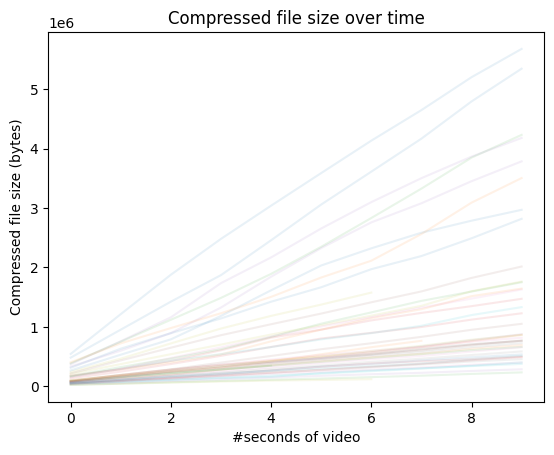

In [7]:
for size in sizes: 
    plt.plot(size, alpha=0.1)
plt.xlabel('#seconds of video')
plt.ylabel('Compressed file size (bytes)')
plt.title('Compressed file size over time')
plt.savefig('results/compressed_file_size_over_time.png')

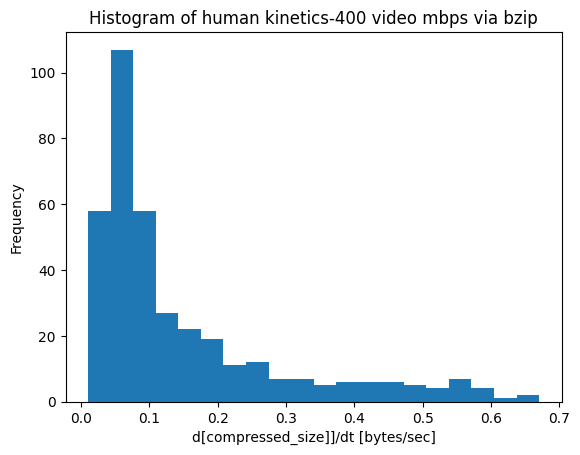

In [8]:
# compute slopes for each 
slopes = []
for size in sizes:
    slopes.append([size[i+1] - size[i] for i in range(len(size)-1)])

# histogram 
slopes_mbps = []
for slope in slopes: 
    for s in slope: 
        slmb = s / 1e6
        slopes_mbps.append(slmb)

plt.figure()
plt.hist(slopes_mbps, bins=20)
plt.xlabel('d[compressed_size]]/dt [bytes/sec]')
plt.ylabel('Frequency')
plt.title('Histogram of human kinetics-400 video mbps via bzip')

plt.savefig('results/histogram_of_human_kinetics-400_video_mbps_via_bzip.png')